In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

In [15]:
matches = pd.read_csv("atp_matches_2010_2024_missing_handled.csv", parse_dates=["tourney_date"])
elo = pd.read_csv("tennis_elo_with_margin.csv")

# Filter Matches from Last 365 Days

In [16]:
end_date = matches["tourney_date"].max()
start_date = end_date - pd.Timedelta(days=365)
recent_matches = matches[matches["tourney_date"] >= start_date].copy()
recent_matches["in_last_30"] = (recent_matches["tourney_date"] >= end_date - pd.Timedelta(days=30)).astype(int)

In [17]:
merged = recent_matches.merge(
    elo[["tourney_id", "match_num", "winner_elo_before", "loser_elo_before"]],
    on=["tourney_id", "match_num"], how="inner"
)

# Generate Player-Level Match Stats (Winner and Loser Entries)

In [18]:
def create_player_rows(df):
    winner_df = pd.DataFrame({
        "player_id": df["winner_id"],
        "player_name": df["winner_name"],
        "hand": df["winner_hand"],
        "height": df["winner_ht"],
        "age": df["winner_age"],
        "surface": df["surface"],
        "aces": df["w_ace"],
        "dfs": df["w_df"],
        "serve_pts": df["w_svpt"],
        "first_in": df["w_1stIn"],
        "first_won": df["w_1stWon"],
        "second_won": df["w_2ndWon"],
        "bp_saved": df["w_bpSaved"],
        "bp_faced": df["w_bpFaced"],
        "bp_converted": df["l_bpFaced"] - df["l_bpSaved"],
        "bp_opps": df["l_bpFaced"],
        "ret_pts_won": df["l_svpt"] - (df["l_1stWon"] + df["l_2ndWon"]),
        "ret_pts_total": df["l_svpt"],
        "match_duration": df["minutes"],
        "elo": df["winner_elo_before"],
        "in_last_30": df["in_last_30"],
        "win": 1
    })
    loser_df = pd.DataFrame({
        "player_id": df["loser_id"],
        "player_name": df["loser_name"],
        "hand": df["loser_hand"],
        "height": df["loser_ht"],
        "age": df["loser_age"],
        "surface": df["surface"],
        "aces": df["l_ace"],
        "dfs": df["l_df"],
        "serve_pts": df["l_svpt"],
        "first_in": df["l_1stIn"],
        "first_won": df["l_1stWon"],
        "second_won": df["l_2ndWon"],
        "bp_saved": df["l_bpSaved"],
        "bp_faced": df["l_bpFaced"],
        "bp_converted": df["w_bpFaced"] - df["w_bpSaved"],
        "bp_opps": df["w_bpFaced"],
        "ret_pts_won": df["w_svpt"] - (df["w_1stWon"] + df["w_2ndWon"]),
        "ret_pts_total": df["w_svpt"],
        "match_duration": df["minutes"],
        "elo": df["loser_elo_before"],
        "in_last_30": df["in_last_30"],
        "win": 0
    })
    return pd.concat([winner_df, loser_df], ignore_index=True)

player_matches = create_player_rows(merged)

# Aggregate Player Stats 

In [19]:
grouped = player_matches.groupby(["player_id", "player_name"])

agg = grouped.agg({
    "hand": "first",
    "height": "median",
    "age": "mean",
    "aces": "sum",
    "dfs": "sum",
    "serve_pts": "sum",
    "first_in": "sum",
    "first_won": "sum",
    "second_won": "sum",
    "bp_saved": "sum",
    "bp_faced": "sum",
    "bp_converted": "sum",
    "bp_opps": "sum",
    "ret_pts_won": "sum",
    "ret_pts_total": "sum",
    "match_duration": "sum",
    "elo": "mean",
    "in_last_30": "sum",
    "win": "sum",
    "surface": lambda x: list(x)
}).reset_index()

# Computing the features

In [20]:
agg["ace_rate"] = agg["aces"] / agg["serve_pts"]
agg["df_rate"] = agg["dfs"] / agg["serve_pts"]
agg["first_serve_pct"] = agg["first_in"] / agg["serve_pts"]
agg["bp_saved_rate"] = np.where(agg["bp_faced"] > 0, agg["bp_saved"] / agg["bp_faced"], 1.0)
agg["bp_conv_rate"] = np.where(agg["bp_opps"] > 0, agg["bp_converted"] / agg["bp_opps"], 0.0)
agg["return_pts_won"] = agg["ret_pts_won"] / agg["ret_pts_total"]
agg["avg_duration"] = agg["match_duration"] / (agg["win"] + 1)
agg["matches_30d"] = agg["in_last_30"]
agg["elo_mean"] = agg["elo"]

# Surface Win Rates 

In [21]:
agg["total_matches"] = agg["surface"].apply(len)
agg["matches_clay"] = agg["surface"].apply(lambda s: s.count("Clay"))
agg["matches_hard"] = agg["surface"].apply(lambda s: s.count("Hard"))
agg["matches_grass"] = agg["surface"].apply(lambda s: s.count("Grass"))
agg["winrate_clay"] = agg["matches_clay"] / agg["total_matches"]
agg["winrate_hard"] = agg["matches_hard"] / agg["total_matches"]
agg["winrate_grass"] = agg["matches_grass"] / agg["total_matches"]

# Filtering players with >= 20 Matches

In [22]:
agg = agg[agg["total_matches"] >= 20].copy()

# Making the final feature matrix 

In [23]:
agg["hand_code"] = agg["hand"].map({"R": 0, "L": 1})
features = agg[[
    "ace_rate", "df_rate", "first_serve_pct", "bp_saved_rate", "bp_conv_rate",
    "return_pts_won", "matches_30d", "avg_duration", "elo_mean",
    "winrate_clay", "winrate_hard", "winrate_grass", "age", "height", "hand_code"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# K means clustering 

In [24]:
k = 6
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
agg["cluster"] = kmeans.fit_predict(X_scaled)

#  t-SNE Visualization

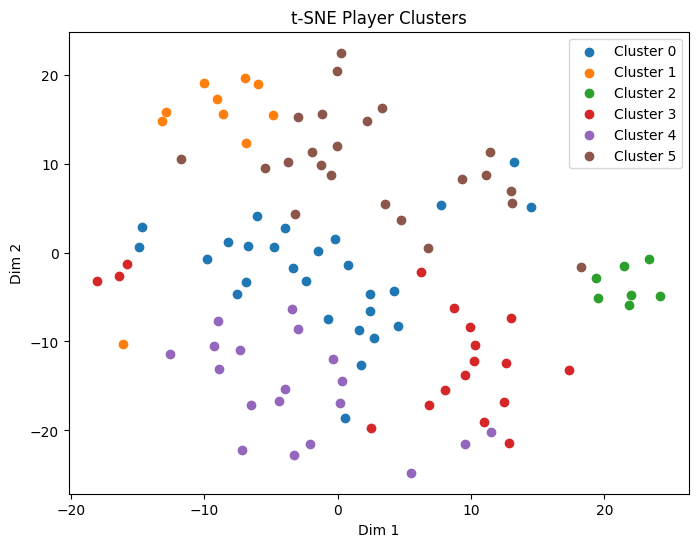

In [25]:
X_embedded = TSNE(n_components=2, perplexity=10, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(8,6))
for label in range(k):
    plt.scatter(
        X_embedded[agg["cluster"] == label, 0],
        X_embedded[agg["cluster"] == label, 1],
        label=f"Cluster {label}"
    )
plt.legend()
plt.title("t-SNE Player Clusters")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [26]:
agg[["player_id", "player_name", "cluster"]].to_csv("player_clusters.csv", index=False)
agg[["player_id", "player_name", "cluster"]].head()

,player_id,player_name,cluster
0,100644,Alexander Zverev,4
6,104527,Stan Wawrinka,5
7,104745,Rafael Nadal,1
9,104792,Gael Monfils,0
13,104925,Novak Djokovic,4
